Class Distribution:
Toxic_conversation
0    0.749983
1    0.250017
Name: proportion, dtype: float64


Evaluating Logistic Regression...
Average Accuracy: 0.7333
Average F1 Score: 0.5135
--------------------------------------------------
Evaluating Support Vector Machine...
Average Accuracy: 0.7315
Average F1 Score: 0.5260
--------------------------------------------------
Evaluating Random Forest...
Average Accuracy: 0.7318
Average F1 Score: 0.4124
--------------------------------------------------

Selected best model based on F1 score: Support Vector Machine

Final Test Performance:
Test Accuracy: 0.7465
Test F1 Score: 0.5484

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.79      0.82      4312
           1       0.50      0.61      0.55      1452

    accuracy                           0.75      5764
   macro avg       0.68      0.70      0.69      5764
weighted avg       0.77      0.75      0.75      5764

Confusion Mat

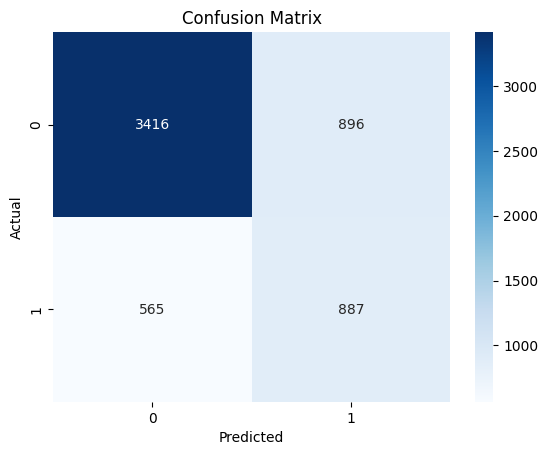

In [ ]:
# Part A - Model Selection Instructions

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('project_data.csv')

# Remove rows with empty values
df = df.dropna()

# Remove duplicated rows
df = df.drop_duplicates()

# Rename columns to match project instructions
df = df.rename(columns={'TOXICITY_x': 'Toxicity'})

# Create new variables
df['Total_toxic_replies'] = df['Num_toxic_direct_replies'] + df['Num_toxic_nested_replies']
df['Toxic_conversation'] = df['Total_toxic_replies'].apply(lambda x: 1 if x > 0 else 0)

# Check class distribution
print("Class Distribution:")
print(df['Toxic_conversation'].value_counts(normalize=True))
print("\n")

# Define features and target
features = ['Length', 'Num_users', 'Toxicity', 'Num_author_replies', 'Verified', 'Age']
X = df[features]
y = df['Toxic_conversation']

# Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize models with class weighting for imbalance
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Support Vector Machine": SVC(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42)
}

# Evaluate each model
results = {}
for name, model in models.items():
    print(f"Evaluating {name}...")

    # Cross-validation for accuracy
    acc_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    avg_acc = np.mean(acc_scores)

    # Cross-validation for F1 score
    f1_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
    avg_f1 = np.mean(f1_scores)

    print(f"Average Accuracy: {avg_acc:.4f}")
    print(f"Average F1 Score: {avg_f1:.4f}")
    print("-" * 50)

    results[name] = {'accuracy': avg_acc, 'f1': avg_f1}

# Select best model based on F1 score
best_model_name = max(results.keys(), key=lambda x: results[x]['f1'])
best_model = models[best_model_name]

print(f"\nSelected best model based on F1 score: {best_model_name}")

# Retrain best model on full training data
best_model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred = best_model.predict(X_test_scaled)

# Evaluate
test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)

print(f"\nFinal Test Performance:")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

# Additional evaluation metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Feature importance (if Random Forest was selected)
if best_model_name == "Random Forest":
    print("\nFeature Importances:")
    importances = best_model.feature_importances_
    for feature, importance in zip(features, importances):
        print(f"{feature}: {importance:.4f}")

    plt.barh(features, importances)
    plt.xlabel('Importance')
    plt.title('Feature Importances')
    plt.show()
elif best_model_name == "Logistic Regression":
    print("\nModel Coefficients:")
    for feature, coef in zip(features, best_model.coef_[0]):
        print(f"{feature}: {coef:.4f}")


Evaluating Regular Logistic Regression...
Average Accuracy: 0.7318
Average F1 Score: 0.5139

Evaluating L1 Regularization (Lasso)...
Average Accuracy: 0.7319
Average F1 Score: 0.5135

L1 Coefficients Analysis:
           Feature  Coefficient
            Length     4.882759
         Num_users    -2.265715
          Toxicity     0.441980
Num_author_replies    -0.400173
          Verified     0.116264
      Listed_count     0.085369
        Num_tweets     0.064760
          Location    -0.043315
               Age    -0.039815
           Friends     0.017065
         Followers    -0.011877

Features shrunk to zero by L1: []

Evaluating L2 Regularization (Ridge)...
Average Accuracy: 0.7323
Average F1 Score: 0.5143

Evaluating Elastic Net Regularization...
Average Accuracy: 0.7316
Average F1 Score: 0.5131


=== Final Regularization Comparison ===
                             accuracy        f1
L2 Regularization (Ridge)    0.732281  0.514258
Regular Logistic Regression  0.731804  0.513912
L

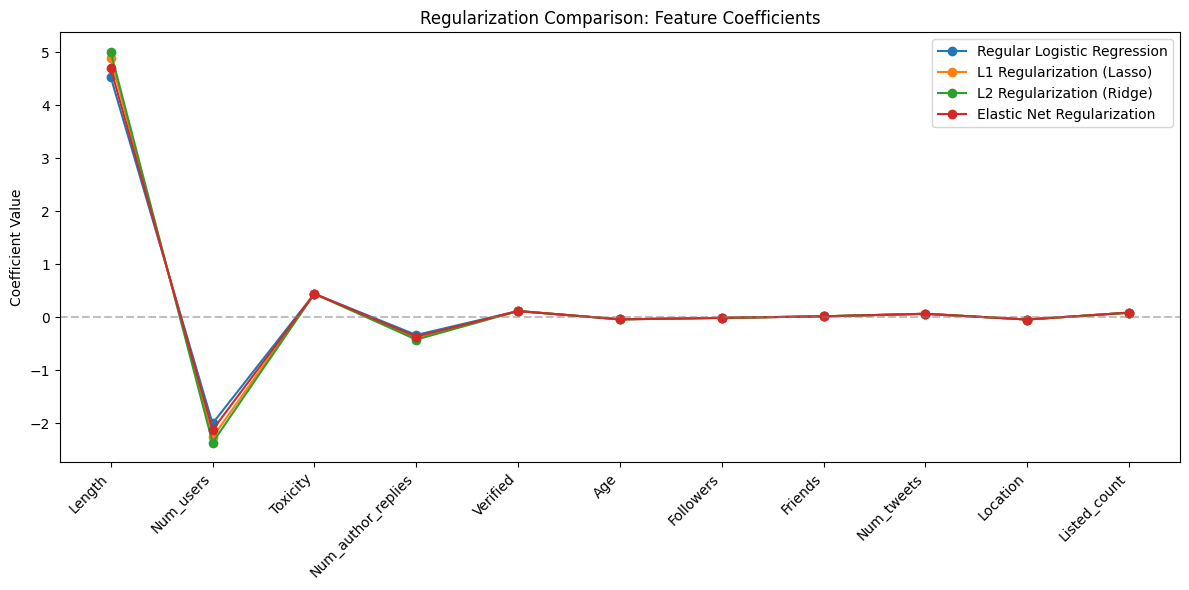

In [ ]:
# Part B - Regularization Instructions

# Define expanded features
expanded_features = ['Length', 'Num_users', 'Toxicity', 'Num_author_replies', 'Verified', 'Age',
                    'Followers', 'Friends', 'Num_tweets', 'Location', 'Listed_count']

X_exp = df[expanded_features]
y_exp = df['Toxic_conversation']

# Split data
X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(X_exp, y_exp, test_size=0.2, random_state=42)

# Standardize features
scaler_exp = StandardScaler()
X_train_exp_scaled = scaler_exp.fit_transform(X_train_exp)
X_test_exp_scaled = scaler_exp.transform(X_test_exp)

# Initialize regularization results storage
results = {}

def evaluate_model(model, name, X_train, y_train):
    print(f"\nEvaluating {name}...")

    # Cross-validation for accuracy and F1
    acc_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')

    avg_acc = np.mean(acc_scores)
    avg_f1 = np.mean(f1_scores)

    print(f"Average Accuracy: {avg_acc:.4f}")
    print(f"Average F1 Score: {avg_f1:.4f}")

    # Fit model to examine coefficients
    model.fit(X_train, y_train)

    # Store results
    results[name] = {
        'accuracy': avg_acc,
        'f1': avg_f1,
        'model': model
    }

    return model

# 1. Regular Logistic Regression (with increased max_iter and balanced class weight)
lr = evaluate_model(
    LogisticRegression(max_iter=5000, solver='saga', class_weight='balanced', random_state=42),
    "Regular Logistic Regression",
    X_train_exp_scaled,
    y_train_exp
)

# 2. L1 Regularization (Lasso)
lr_l1 = evaluate_model(
    LogisticRegression(penalty='l1', C=1.0, solver='saga', max_iter=5000, class_weight='balanced', random_state=42),
    "L1 Regularization (Lasso)",
    X_train_exp_scaled,
    y_train_exp
)

# Print L1 coefficients
print("\nL1 Coefficients Analysis:")
l1_coefs = pd.DataFrame({
    'Feature': expanded_features,
    'Coefficient': lr_l1.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print(l1_coefs.to_string(index=False))

# Identify zeroed-out features
zeroed_features = l1_coefs[l1_coefs['Coefficient'].abs() < 1e-6]['Feature'].tolist()
print(f"\nFeatures shrunk to zero by L1: {zeroed_features}")

# 3. L2 Regularization (Ridge)
lr_l2 = evaluate_model(
    LogisticRegression(penalty='l2', C=1.0, max_iter=5000, class_weight='balanced', random_state=42),
    "L2 Regularization (Ridge)",
    X_train_exp_scaled,
    y_train_exp
)

# 4. Elastic Net Regularization
lr_en = evaluate_model(
    LogisticRegression(penalty='elasticnet', l1_ratio=0.5, C=1.0, solver='saga',
                     max_iter=5000, class_weight='balanced', random_state=42),
    "Elastic Net Regularization",
    X_train_exp_scaled,
    y_train_exp
)

# Compare all results
print("\n\n=== Final Regularization Comparison ===")
comparison_df = pd.DataFrame.from_dict(results, orient='index')[['accuracy', 'f1']]
print(comparison_df.sort_values('f1', ascending=False))

# Analysis of best performing model
best_model_name = comparison_df['f1'].idxmax()
best_model = results[best_model_name]['model']
print(f"\nBest performing model: {best_model_name}")

# Test set evaluation of best model
y_pred = best_model.predict(X_test_exp_scaled)
print("\nBest Model Test Performance:")
print(f"Accuracy: {accuracy_score(y_test_exp, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test_exp, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_exp, y_pred))

# Visualize coefficients comparison
plt.figure(figsize=(12, 6))
for i, (name, res) in enumerate(results.items()):
    if hasattr(res['model'], 'coef_'):
        plt.plot(res['model'].coef_[0], 'o-', label=name)

plt.xticks(range(len(expanded_features)), expanded_features, rotation=45, ha='right')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.ylabel('Coefficient Value')
plt.title('Regularization Comparison: Feature Coefficients')
plt.legend()
plt.tight_layout()
plt.show()

## Regularization Techniques Comparison and Analysis

### Performance Comparison

Our regularization techniques showed similar but slightly different performance:

1. **L2 Regularization (Ridge)** performed best with:
   - CV F1: 0.5143
   - Test F1: 0.5270
2. **Standard Logistic Regression** came pretty close behind
3. **L1 (Lasso)** and **Elastic Net** showed a marginally lower performance

This suggests to us that:
- Most features contribute meaningfully to prediction (favoring L2)
- Complete feature elimination (L1) wasn't beneficial for this dataset
- The compromise of Elastic Net (α=0.5) didn't provide additional value

### Coefficient Analysis

From the coefficients visualization and L1 output:

**Most Important Features**:
1. `Length` (strong positive impact)
2. `Num_users` (strong negative impact)
3. `Toxicity` (moderate positive impact)
4. `Num_author_replies` (moderate negative impact)

**Interesting Findings**:
- No features were completely eliminated by L1 regularization
- `Verified` and `Listed_count` had small but consistent positive effects
- Social features (`Followers`, `Friends`) showed minimal impact
- `Location` had negligible effect despite being included

### Why L2 Performed Best

Ridge regression pulled ahead because:

1. Most features matter, even if only slightly

2. L2 keeps weak but useful signals by shrinking instead of dropping them

3. Better with correlated features, which L1 tends to penalize too harshly

### Practical Implications

For toxicity prediction:
1. **Conversation structure matters**: things like length and how many users are involved are major predictors
2. **Author behavior counts**: especially their reply count and past toxicity
3. **Profile characteristics** doesn’t tell us much, aside from whether someone is verified

### Limitations and Future Work

1. Could try **engineering interaction terms** between features

2. More **hyperparameter tuning** (C values, l1_ratios) might help

3. Might be worth trying **non-linear models** like neural networks

> **Key Insight**: Most features play a role, but metadata around the conversation itself (like length and user count) does way more for predicting toxicity than profile stats or social connections.